# 🔬 Análise dos Filtros Wavelet Aprendidos (Financial)

## Objetivo
Verificar se os filtros aprendidos pelo `LearnedWaveletDWT1D_QMF` nos melhores modelos
financeiros atendem às propriedades matemáticas de filtros wavelet válidos.

## Propriedades Verificadas
1. **Admissibilidade** – média zero do filtro high-pass (função mãe wavelet)
2. **Normalização** – norma L2 unitária dos filtros
3. **QMF (Quadrature Mirror Filter)** – relação $g[n] = (-1)^n h[L{-}1{-}n]$
4. **Perfect Reconstruction** – condição de Nyquist: $|H(\omega)|^2 + |H(\omega+\pi)|^2 = 2$
5. **Resposta em frequência** – filtro low-pass é passa-baixa e high-pass é passa-alta
6. **Localização tempo-frequência** – produto $\Delta t \cdot \Delta \omega$
7. **Comparação com wavelets clássicas** – vis-à-vis db2, db4, coif1, sym4
8. **Vanishing moments** – análise numérica do número de momentos nulos
9. **Diversidade entre canais e níveis**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
import warnings
import json, zipfile, io, h5py
from pathlib import Path
warnings.filterwarnings('ignore')

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import tensorflow as tf
from tensorflow.keras.models import load_model

import sys
sys.path.append('.')
sys.path.append('../../models')
from LWT import LearnedWaveletDWT1D_QMF, LearnedWaveletPair1D_QMF
from dl_utils import PatchEmbedding, TransformerBlock, SinusoidalPositionalEncoding

from config.experiment_config import (
    LEARNED_WAVELET_CONFIG, FEATURE_CONFIG, TICKERS,
    DL_MODELS, MODES, FEATURE_MODES, RESULTS_CONFIG,
)

plt.style.use('seaborn-v0_8-whitegrid')

# Construir caminhos a partir da raiz do experimento
BASE_DIR = Path('.').resolve()
RESULTS_DIR = BASE_DIR / RESULTS_CONFIG['results_dir']
FILTER_DIR = RESULTS_DIR / '2026-05-03' / 'filter_analysis'
FILTER_DIR.mkdir(parents=True, exist_ok=True)

# Diretório dos modelos salvos
RUN_DIR = sorted(RESULTS_DIR.glob('????-??-??*'))[-1]
SAVED_MODELS_DIR = RUN_DIR / 'saved_models'

print(f'TensorFlow: {tf.__version__}')
print(f'Run: {RUN_DIR.name}')
print(f'LWT config: levels={LEARNED_WAVELET_CONFIG["levels"]}, kernel_size={LEARNED_WAVELET_CONFIG["kernel_size"]}')
print(f'Sequence length: {FEATURE_CONFIG["sequence_length"]}')
print('✅ Imports realizados com sucesso!')

I0000 00:00:1780190554.105405 1863088 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0
Run: 2026-05-03
LWT config: levels=2, kernel_size=8
Sequence length: 40
✅ Imports realizados com sucesso!


## 1. Localizar o Melhor Modelo Learned Wavelet

In [2]:
# Ler meta_summary para encontrar os melhores modelos
meta_path = RUN_DIR / 'meta_summary.csv'
df_meta = pd.read_csv(meta_path)

lw_mask = df_meta['mode'].str.contains('learned_wavelet', na=False)
df_lw = df_meta[lw_mask].copy()
print(f'Total modelos learned_wavelet: {len(df_lw)}')

# Top-5 por Sharpe
top5 = df_lw.nlargest(5, 'primary_sharpe')[['feature_mode','ticker','model','mode','primary_sharpe','primary_total_return']]
print('\nTop-5 por Sharpe:')
print(top5.to_string(index=False))

# Selecionar o melhor
best_row = df_lw.loc[df_lw['primary_sharpe'].idxmax()]
best_fmode = best_row['feature_mode']
best_ticker = best_row['ticker']
best_model = best_row['model']
best_mode = best_row['mode']
print(f'\n✅ Melhor: {best_model} ({best_mode}) | {best_ticker} | {best_fmode} | Sharpe={best_row["primary_sharpe"]:.4f}')

# Caminho do modelo salvo (fold_0)
model_dir = SAVED_MODELS_DIR / best_fmode / best_ticker / f'{best_model}_{best_mode}'
model_path = model_dir / 'fold_0.keras'
print(f'Model path: {model_path}')
assert model_path.exists(), f'Modelo não encontrado: {model_path}'

Total modelos learned_wavelet: 200

Top-5 por Sharpe:


feature_mode   ticker    model                      mode  primary_sharpe  primary_total_return
       ohlcv SUZB3.SA CNN_LSTM           learned_wavelet        2.275291              0.320652
       ohlcv COGN3.SA CNN_LSTM learned_wavelet_no_warmup        0.671266              0.380737
       ohlcv CYRE3.SA      CNN learned_wavelet_no_warmup        0.583734              0.297679
       ohlcv UGPA3.SA CNN_LSTM           learned_wavelet        0.457924              0.112993
       ohlcv COGN3.SA CNN_LSTM           learned_wavelet        0.399294             -0.014067

✅ Melhor: CNN_LSTM (learned_wavelet) | SUZB3.SA | ohlcv | Sharpe=2.2753
Model path: /home/felipeteodoro/projetos/LearnableWaveletLayer/tests/financial/results/2026-05-03/saved_models/ohlcv/SUZB3.SA/CNN_LSTM_learned_wavelet/fold_0.keras


In [3]:
# O modelo foi treinado com uma versão anterior de LearnedWaveletPair1D_QMF
# onde low_head = Dense(kernel_size) (filtros compartilhados entre canais),
# enquanto a versão atual usa Dense(kernel_size * n_channels).
# Por isso, extraímos os filtros diretamente dos pesos H5.

with zipfile.ZipFile(model_path) as z:
    with z.open('model.weights.h5') as f:
        hf = h5py.File(io.BytesIO(f.read()), 'r')

        # Listar pares de wavelets (um por nível)
        dwt_path = 'layers/learned_wavelet_dwt1d_qmf/pairs'
        pair_names = sorted([k for k in hf[dwt_path].keys()])
        print(f'Pares encontrados: {pair_names}')

        raw_weights = []
        for pname in pair_names:
            ppath = f'{dwt_path}/{pname}'
            w = {
                'base_dense0_W': hf[f'{ppath}/base_net/layers/dense/vars/0'][()],
                'base_dense0_b': hf[f'{ppath}/base_net/layers/dense/vars/1'][()],
                'base_dense1_W': hf[f'{ppath}/base_net/layers/dense_1/vars/0'][()],
                'base_dense1_b': hf[f'{ppath}/base_net/layers/dense_1/vars/1'][()],
                'low_head_W': hf[f'{ppath}/low_head/vars/0'][()],
                'low_head_b': hf[f'{ppath}/low_head/vars/1'][()],
                'raw_scale': hf[f'{ppath}/vars/0'][()],
                'translation': hf[f'{ppath}/vars/1'][()],
            }
            raw_weights.append(w)
            ks = w['low_head_b'].shape[0]
            print(f'  {pname}: kernel_size={ks}, scale(raw)={w["raw_scale"]:.4f}, translation={w["translation"]:.4f}')

print(f'\n✅ Pesos extraídos de {len(raw_weights)} níveis')

Pares encontrados: ['learned_wavelet_pair1d_qmf', 'learned_wavelet_pair1d_qmf_1']
  learned_wavelet_pair1d_qmf: kernel_size=8, scale(raw)=-0.0309, translation=-0.0301
  learned_wavelet_pair1d_qmf_1: kernel_size=8, scale(raw)=-0.0059, translation=-0.0471

✅ Pesos extraídos de 2 níveis


## 2. Extrair Filtros Aprendidos (por canal e por nível)

In [4]:
def extract_filters_from_weights(raw_weights, kernel_size=8):
    """Extrai filtros h e g de cada nível a partir dos pesos brutos do H5."""
    filters_all = []

    for level_idx, w in enumerate(raw_weights):
        ks = w['low_head_b'].shape[0]

        # Reconstruir o vetor de tempos t
        t = np.linspace(-ks // 2, ks // 2, ks, dtype=np.float32).reshape(1, -1)

        # Scale e translation
        scale = float(np.log1p(np.exp(w['raw_scale'])) + 1e-3)  # softplus
        translation = float(w['translation'])
        t_adj = (t - translation) / scale

        # Forward pass pela base_net (2 camadas Dense + ReLU)
        z = t_adj @ w['base_dense0_W'] + w['base_dense0_b']
        z = np.maximum(z, 0)  # ReLU
        z = z @ w['base_dense1_W'] + w['base_dense1_b']
        z = np.maximum(z, 0)  # ReLU

        # low_head → h
        h_flat = z @ w['low_head_W'] + w['low_head_b']
        h = h_flat.flatten()

        # Normalização L2
        h = h / (np.linalg.norm(h) + 1e-8)

        # QMF: g[n] = (-1)^n * h[L-1-n]
        signs = np.array([(-1)**n for n in range(ks)], dtype=np.float32)
        g = signs * h[::-1]

        filters_all.append({
            'level': level_idx + 1,
            'h': h.reshape(1, -1),  # (1, K) — filtro compartilhado
            'g': g.reshape(1, -1),
            'scale': scale,
            'translation': translation,
            'kernel_size': ks,
            'normalize_low': 'l2',
        })
        print(f"Level {level_idx+1}: h.shape={h.shape}, scale={scale:.4f}, translation={translation:.4f}")

    return filters_all

filters = extract_filters_from_weights(raw_weights)
n_levels = len(filters)
# Modelo antigo: filtros compartilhados entre canais
N_CHANNELS = 1
CHANNEL_NAMES = ['Shared']

print(f'\n✅ {n_levels} níveis extraídos, filtros compartilhados entre canais OHLCV')

Level 1: h.shape=(8,), scale=0.6788, translation=-0.0301
Level 2: h.shape=(8,), scale=0.6912, translation=-0.0471

✅ 2 níveis extraídos, filtros compartilhados entre canais OHLCV


## 3. Visualização dos Filtros no Domínio do Tempo

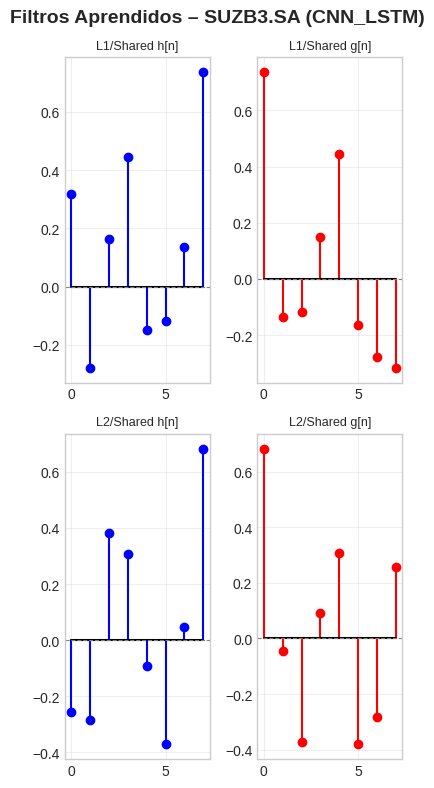

In [5]:
n_cols = min(N_CHANNELS, 5)  # Limitar a 5 canais por linha
fig, axes = plt.subplots(n_levels, n_cols * 2, figsize=(4 * n_cols, 4 * n_levels), squeeze=False)

for i, filt in enumerate(filters):
    for ch in range(n_cols):
        h = filt['h'][ch]
        g = filt['g'][ch]

        ax_h = axes[i, ch * 2]
        ax_h.stem(h, linefmt='b-', markerfmt='bo', basefmt='k-')
        ax_h.set_title(f'L{filt["level"]}/{CHANNEL_NAMES[ch]} h[n]', fontsize=9)
        ax_h.axhline(0, color='gray', ls='--', lw=0.8)
        ax_h.grid(True, alpha=0.3)

        ax_g = axes[i, ch * 2 + 1]
        ax_g.stem(g, linefmt='r-', markerfmt='ro', basefmt='k-')
        ax_g.set_title(f'L{filt["level"]}/{CHANNEL_NAMES[ch]} g[n]', fontsize=9)
        ax_g.axhline(0, color='gray', ls='--', lw=0.8)
        ax_g.grid(True, alpha=0.3)

plt.suptitle(f'Filtros Aprendidos – {best_ticker} ({best_model})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FILTER_DIR / 'filters_time_domain.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Propriedade 1 \u2013 Admissibilidade (M\u00e9dia Zero do High-Pass)

Uma fun\u00e7\u00e3o m\u00e3e wavelet $\psi$ deve satisfazer: $\sum_n g[n] = 0$

In [6]:
print('='*70)
print('PROPRIEDADE 1: Admissibilidade (média zero do high-pass)')
print('='*70)
print(f'{"Nível":>6} {"Canal":>10} | {"sum(g)":>12} | {"Status":>12}')
print('-' * 55)

admissibility_results = []
for filt in filters:
    for ch in range(N_CHANNELS):
        g = filt['g'][ch]
        g_sum = np.sum(g)
        passed = np.abs(g_sum) < 1e-4
        status = '✅ OK' if passed else f'⚠️  Dev={g_sum:.6f}'
        print(f"{filt['level']:>6} {CHANNEL_NAMES[ch]:>10} | {g_sum:>12.8f} | {status:>12}")
        admissibility_results.append({
            'level': filt['level'], 'channel': CHANNEL_NAMES[ch],
            'sum_g': g_sum, 'passed': passed
        })

PROPRIEDADE 1: Admissibilidade (média zero do high-pass)
 Nível      Canal |       sum(g) |       Status
-------------------------------------------------------
     1     Shared |   0.31935474 | ⚠️  Dev=0.319355
     2     Shared |   0.25681290 | ⚠️  Dev=0.256813


## 5. Propriedade 2 \u2013 Normaliza\u00e7\u00e3o (Norma L2 e Soma)

In [7]:
print('='*70)
print('PROPRIEDADE 2: Normaliza\u00e7ão dos Filtros')
print('='*70)
print(f'{"Nível":>6} {"Canal":>10} | {"||h||_2":>10} | {"||g||_2":>10} | {"sum(h)":>10} | {"sum(h)/√2":>10}')
print('-' * 75)

norm_results = []
for filt in filters:
    for ch in range(N_CHANNELS):
        h = filt['h'][ch]
        g = filt['g'][ch]
        h_l2 = np.linalg.norm(h)
        g_l2 = np.linalg.norm(g)
        h_sum = np.sum(h)
        h_ratio = h_sum / np.sqrt(2)
        print(f"{filt['level']:>6} {CHANNEL_NAMES[ch]:>10} | {h_l2:>10.6f} | {g_l2:>10.6f} | {h_sum:>10.6f} | {h_ratio:>10.6f}")
        norm_results.append({
            'level': filt['level'], 'channel': CHANNEL_NAMES[ch],
            'h_l2': h_l2, 'g_l2': g_l2, 'h_sum': h_sum
        })

print(f'\nNota: normaliza\u00e7ão usada = "{filters[0]["normalize_low"]}"')

PROPRIEDADE 2: Normalização dos Filtros
 Nível      Canal |    ||h||_2 |    ||g||_2 |     sum(h) |  sum(h)/√2
---------------------------------------------------------------------------
     1     Shared |   1.000000 |   1.000000 |   1.252383 |   0.885568
     2     Shared |   1.000000 |   1.000000 |   0.409540 |   0.289589

Nota: normalização usada = "l2"


## 6. Propriedade 3 \u2013 Rela\u00e7\u00e3o QMF

$$g[n] = (-1)^n \cdot h[L{-}1{-}n]$$

In [8]:
print('='*70)
print('PROPRIEDADE 3: Rela\u00e7ão QMF  g[n] = (-1)^n * h[L-1-n]')
print('='*70)

for filt in filters:
    for ch in range(N_CHANNELS):
        h = filt['h'][ch]
        g = filt['g'][ch]
        K = len(h)
        sign = np.array([(-1)**n for n in range(K)])
        g_expected = h[::-1] * sign
        error = np.max(np.abs(g - g_expected))
        passed = error < 1e-6
        status = '✅ OK' if passed else f'❌ Erro máx = {error:.2e}'
        print(f'  Nível {filt["level"]} / {CHANNEL_NAMES[ch]}: erro máximo = {error:.2e}  {status}')

PROPRIEDADE 3: Relação QMF  g[n] = (-1)^n * h[L-1-n]
  Nível 1 / Shared: erro máximo = 0.00e+00  ✅ OK
  Nível 2 / Shared: erro máximo = 0.00e+00  ✅ OK


## 7. Propriedade 4 \u2013 Perfect Reconstruction

$$|H(e^{j\omega})|^2 + |H(e^{j(\omega+\pi)})|^2 = 2 \quad \forall \omega$$

PROPRIEDADE 4: Perfect Reconstruction


  Nível 1 / Shared: média=1.9997, desvio=150.68%  ⚠️  150.68%
  Nível 2 / Shared: média=1.9983, desvio=230.86%  ⚠️  230.86%


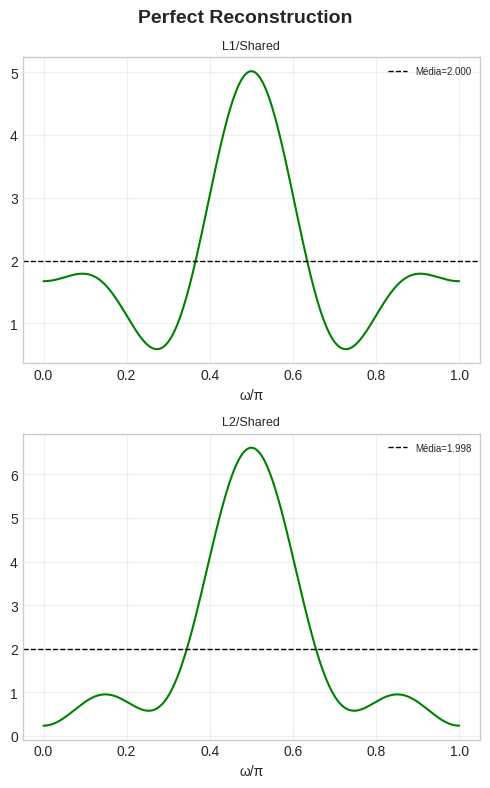

In [9]:
print('='*70)
print('PROPRIEDADE 4: Perfect Reconstruction')
print('='*70)

N_freq = 1024
omega = np.linspace(0, np.pi, N_freq)

n_cols_pr = min(N_CHANNELS, 5)
fig, axes = plt.subplots(n_levels, n_cols_pr, figsize=(5 * n_cols_pr, 4 * n_levels), squeeze=False)

pr_results = []
for i, filt in enumerate(filters):
    for ch in range(N_CHANNELS):
        h = filt['h'][ch]
        K = len(h)

        H = np.zeros(N_freq, dtype=complex)
        H_shifted = np.zeros(N_freq, dtype=complex)
        for n in range(K):
            H += h[n] * np.exp(-1j * omega * n)
            H_shifted += h[n] * np.exp(-1j * (omega + np.pi) * n)

        pr_sum = np.abs(H)**2 + np.abs(H_shifted)**2
        pr_mean = np.mean(pr_sum)
        pr_deviation = np.max(np.abs(pr_sum - pr_mean)) / pr_mean * 100

        passed = pr_deviation < 5.0
        status = '✅ OK' if passed else f'⚠️  {pr_deviation:.2f}%'
        print(f'  Nível {filt["level"]} / {CHANNEL_NAMES[ch]}: média={pr_mean:.4f}, desvio={pr_deviation:.2f}%  {status}')
        pr_results.append({
            'level': filt['level'], 'channel': CHANNEL_NAMES[ch],
            'pr_mean': pr_mean, 'pr_max_deviation_pct': pr_deviation, 'passed': passed
        })

        if ch < n_cols_pr:
            ax = axes[i, ch]
            ax.plot(omega / np.pi, pr_sum, 'g-', lw=1.5)
            ax.axhline(pr_mean, color='k', ls='--', lw=1, label=f'Média={pr_mean:.3f}')
            ax.set_title(f'L{filt["level"]}/{CHANNEL_NAMES[ch]}', fontsize=9)
            ax.set_xlabel('\u03c9/\u03c0')
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)

plt.suptitle('Perfect Reconstruction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FILTER_DIR / 'perfect_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Resposta em Frequ\u00eancia

RESPOSTA EM FREQUÊNCIA
  Nível 1 / Shared: h low=44.3% ⚠️ | g high=44.6% ⚠️
  Nível 2 / Shared: h low=67.4% ✅ | g high=67.7% ✅


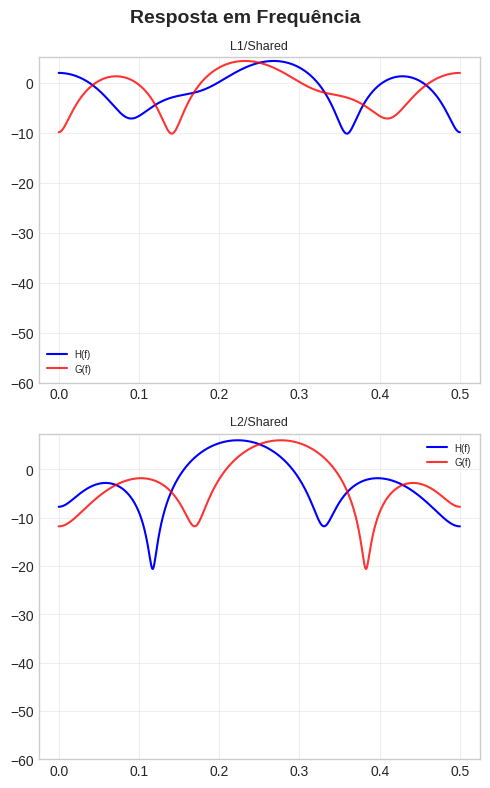

In [10]:
N_fft = 2048

n_cols_fr = min(N_CHANNELS, 5)
fig, axes = plt.subplots(n_levels, n_cols_fr, figsize=(5 * n_cols_fr, 4 * n_levels), squeeze=False)

print('='*70)
print('RESPOSTA EM FREQU\u00caNCIA')
print('='*70)

for i, filt in enumerate(filters):
    for ch in range(N_CHANNELS):
        h = filt['h'][ch]
        g = filt['g'][ch]

        H = np.abs(np.fft.rfft(h, n=N_fft))
        G = np.abs(np.fft.rfft(g, n=N_fft))
        freqs = np.fft.rfftfreq(N_fft)

        half = len(freqs) // 2
        h_ratio = np.sum(H[:half]**2) / (np.sum(H**2) + 1e-12)
        g_ratio = np.sum(G[half:]**2) / (np.sum(G**2) + 1e-12)

        h_ok = '✅' if h_ratio > 0.6 else '⚠️'
        g_ok = '✅' if g_ratio > 0.6 else '⚠️'
        print(f'  Nível {filt["level"]} / {CHANNEL_NAMES[ch]}: h low={h_ratio*100:.1f}% {h_ok} | g high={g_ratio*100:.1f}% {g_ok}')

        if ch < n_cols_fr:
            ax = axes[i, ch]
            H_db = 20 * np.log10(H + 1e-12)
            G_db = 20 * np.log10(G + 1e-12)
            ax.plot(freqs, H_db, 'b-', label='H(f)', lw=1.5)
            ax.plot(freqs, G_db, 'r-', label='G(f)', lw=1.5, alpha=0.8)
            ax.set_title(f'L{filt["level"]}/{CHANNEL_NAMES[ch]}', fontsize=9)
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)
            ax.set_ylim(bottom=-60)

plt.suptitle('Resposta em Frequ\u00eancia', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FILTER_DIR / 'frequency_response.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Vanishing Moments do High-Pass

$$\sum_n n^k \cdot g[n] = 0, \quad k = 0, 1, \ldots, N{-}1$$

In [11]:
print('='*70)
print('VANISHING MOMENTS DO HIGH-PASS g')
print('='*70)

vm_results = []
for filt in filters:
    for ch in range(N_CHANNELS):
        g = filt['g'][ch]
        K = len(g)
        n_arr = np.arange(K, dtype=float)

        n_vanishing = 0
        for k in range(min(10, K)):
            moment = np.sum((n_arr ** k) * g)
            is_zero = np.abs(moment) < 1e-3
            if is_zero and k == n_vanishing:
                n_vanishing = k + 1

        vm_results.append({
            'level': filt['level'], 'channel': CHANNEL_NAMES[ch],
            'vanishing_moments': n_vanishing
        })
        print(f'  Nível {filt["level"]} / {CHANNEL_NAMES[ch]}: vanishing moments = {n_vanishing}')

print('\n  Refer\u00eancia (wavelets cl\u00e1ssicas):')
for wname in ['db1', 'db2', 'db4', 'coif1', 'sym4']:
    w = pywt.Wavelet(wname)
    print(f'    {wname:>6}: vanishing moments = {w.dec_len // 2}')

VANISHING MOMENTS DO HIGH-PASS g
  Nível 1 / Shared: vanishing moments = 0
  Nível 2 / Shared: vanishing moments = 0

  Referência (wavelets clássicas):
       db1: vanishing moments = 1
       db2: vanishing moments = 2
       db4: vanishing moments = 4
     coif1: vanishing moments = 3
      sym4: vanishing moments = 4


## 10. Compara\u00e7\u00e3o com Wavelets Cl\u00e1ssicas

In [12]:
classic_wavelets = {
    'db2': pywt.Wavelet('db2'),
    'db4': pywt.Wavelet('db4'),
    'sym4': pywt.Wavelet('sym4'),
    'coif1': pywt.Wavelet('coif1'),
}

def resample_filter(f, target_len):
    x_old = np.linspace(0, 1, len(f))
    x_new = np.linspace(0, 1, target_len)
    return np.interp(x_new, x_old, f)

print('='*70)
print('COMPARA\u00c7\u00c3O: Filtros Aprendidos vs Wavelets Cl\u00e1ssicas (correla\u00e7ão Pearson)')
print('='*70)

corr_all = []
for filt in filters:
    for ch in range(N_CHANNELS):
        h_learned = filt['h'][ch]
        row = {'Nível': filt['level'], 'Canal': CHANNEL_NAMES[ch]}
        for wname, w in classic_wavelets.items():
            h_classic = resample_filter(np.array(w.dec_lo), len(h_learned))
            h_l = (h_learned - np.mean(h_learned)) / (np.std(h_learned) + 1e-12)
            h_c = (h_classic - np.mean(h_classic)) / (np.std(h_classic) + 1e-12)
            row[wname] = np.corrcoef(h_l, h_c)[0, 1]
        corr_all.append(row)

corr_df = pd.DataFrame(corr_all)
print(corr_df.to_string(index=False))

for _, row in corr_df.iterrows():
    wnames_only = {k: abs(v) for k, v in row.items() if k not in ('Nível', 'Canal')}
    best_w = max(wnames_only, key=wnames_only.get)
    print(f'  Nível {int(row["Nível"])} / {row["Canal"]}: mais similar a {best_w} (|r| = {wnames_only[best_w]:.4f})')

COMPARAÇÃO: Filtros Aprendidos vs Wavelets Clássicas (correlação Pearson)
 Nível  Canal       db2       db4     sym4     coif1
     1 Shared -0.082688 -0.147606 0.245995 -0.379918
     2 Shared  0.076201 -0.194110 0.491940 -0.260453


  Nível 1 / Shared: mais similar a coif1 (|r| = 0.3799)
  Nível 2 / Shared: mais similar a sym4 (|r| = 0.4919)


## 11. Localiza\u00e7\u00e3o Tempo-Frequ\u00eancia

$$\Delta t \cdot \Delta \omega \geq \frac{1}{2}$$

In [13]:
def time_freq_product(h):
    h = np.array(h, dtype=float)
    h2 = h**2
    h2_sum = np.sum(h2)
    if h2_sum < 1e-12:
        return np.inf, np.inf, np.inf
    h2_norm = h2 / h2_sum
    n = np.arange(len(h), dtype=float)
    t_mean = np.sum(n * h2_norm)
    t_var = np.sum((n - t_mean)**2 * h2_norm)
    delta_t = np.sqrt(t_var)
    N_fft_loc = max(2048, len(h) * 16)
    H = np.abs(np.fft.rfft(h, n=N_fft_loc))
    H2 = H**2
    H2_sum = np.sum(H2)
    if H2_sum < 1e-12:
        return delta_t, np.inf, np.inf
    H2_norm = H2 / H2_sum
    freqs = np.fft.rfftfreq(N_fft_loc)
    f_mean = np.sum(freqs * H2_norm)
    f_var = np.sum((freqs - f_mean)**2 * H2_norm)
    delta_f = np.sqrt(f_var)
    return delta_t, delta_f, delta_t * delta_f

print('='*70)
print('LOCALIZA\u00c7\u00c3O TEMPO-FREQU\u00caNCIA')
print('='*70)
print(f'{"Filtro":>30} | {"Δt":>8} | {"Δω":>8} | {"Δt·Δω":>10}')
print('-' * 65)

for filt in filters:
    for ch in range(N_CHANNELS):
        dt, df, prod = time_freq_product(filt['h'][ch])
        label = f'L{filt["level"]}/{CHANNEL_NAMES[ch]}'
        print(f'{label:>30} | {dt:>8.4f} | {df:>8.4f} | {prod:>10.4f}')

print('-' * 65)
for wname, w in classic_wavelets.items():
    dt, df, prod = time_freq_product(np.array(w.dec_lo))
    print(f'{wname:>30} | {dt:>8.4f} | {df:>8.4f} | {prod:>10.4f}')
print('\nMenor produto = melhor localiza\u00e7ão (limite inferior: 0.5)')

LOCALIZAÇÃO TEMPO-FREQUÊNCIA
                        Filtro |       Δt |       Δω |      Δt·Δω
-----------------------------------------------------------------


                     L1/Shared |   2.6363 |   0.1267 |     0.3342
                     L2/Shared |   2.5249 |   0.0850 |     0.2147
-----------------------------------------------------------------
                           db2 |   0.5728 |   0.0904 |     0.0518
                           db4 |   0.7762 |   0.0822 |     0.0638
                          sym4 |   0.6522 |   0.0822 |     0.0536
                         coif1 |   0.5528 |   0.0899 |     0.0497

Menor produto = melhor localização (limite inferior: 0.5)


## 12. Diversidade entre Canais e N\u00edveis

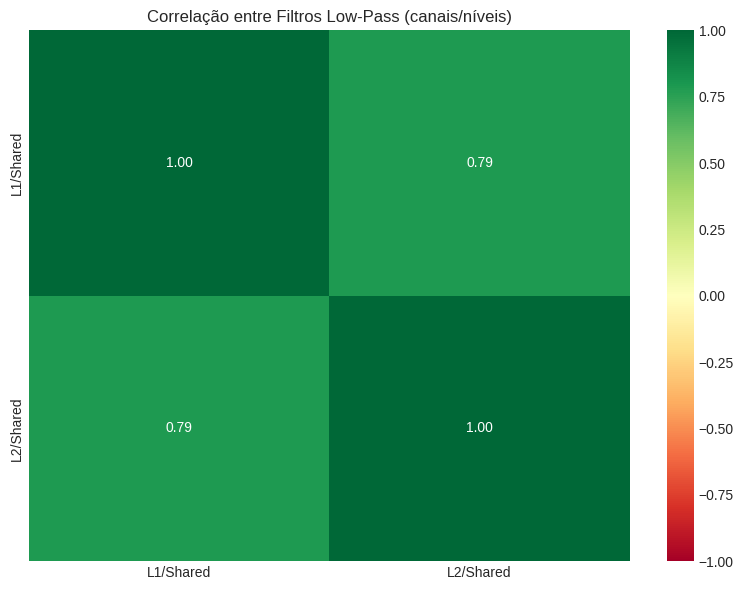


Diversidade entre CANAIS (mesmo nível):
  Nível 1: correlação média entre canais = 0.0000
  Nível 2: correlação média entre canais = 0.0000

Diversidade entre NÍVEIS (mesmo canal):
  Shared: correlação média entre níveis = 0.7874


In [14]:
import seaborn as sns

all_h = []
labels_h = []
for filt in filters:
    for ch in range(N_CHANNELS):
        all_h.append(filt['h'][ch])
        labels_h.append(f'L{filt["level"]}/{CHANNEL_NAMES[ch]}')

n_total = len(all_h)
cross_corr = np.zeros((n_total, n_total))
for i in range(n_total):
    for j in range(n_total):
        cross_corr[i, j] = np.corrcoef(all_h[i], all_h[j])[0, 1]

fig, ax = plt.subplots(1, 1, figsize=(max(8, n_total * 0.8), max(6, n_total * 0.6)))
sns.heatmap(cross_corr, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=labels_h, yticklabels=labels_h, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Correla\u00e7ão entre Filtros Low-Pass (canais/n\u00edveis)')
plt.tight_layout()
plt.savefig(FILTER_DIR / 'cross_channel_level_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDiversidade entre CANAIS (mesmo nível):')
for filt in filters:
    ch_corrs = []
    for c1 in range(N_CHANNELS):
        for c2 in range(c1+1, N_CHANNELS):
            r = np.corrcoef(filt['h'][c1], filt['h'][c2])[0, 1]
            ch_corrs.append(r)
    mean_r = np.mean(ch_corrs) if ch_corrs else 0
    print(f'  Nível {filt["level"]}: correla\u00e7ão média entre canais = {mean_r:.4f}')

if n_levels > 1:
    print('\nDiversidade entre N\u00cdVEIS (mesmo canal):')
    for ch in range(N_CHANNELS):
        lv_corrs = []
        for i in range(n_levels):
            for j in range(i+1, n_levels):
                r = np.corrcoef(filters[i]['h'][ch], filters[j]['h'][ch])[0, 1]
                lv_corrs.append(r)
        mean_r = np.mean(lv_corrs)
        print(f'  {CHANNEL_NAMES[ch]}: correla\u00e7ão média entre n\u00edveis = {mean_r:.4f}')

## 13. Relat\u00f3rio Consolidado

In [15]:
print('\n' + '='*80)
print('\U0001f4ca RELAT\u00d3RIO CONSOLIDADO \u2014 An\u00e1lise dos Filtros Aprendidos (Financial)')
print(f'   Modelo: {best_model} ({best_mode}) | Ticker: {best_ticker} | Features: {best_fmode}')
print('='*80)

summary_rows = []
vm_idx = 0
pr_idx = 0
for filt in filters:
    for ch in range(N_CHANNELS):
        h = filt['h'][ch]
        g = filt['g'][ch]
        K = len(h)

        g_sum = np.sum(g)
        h_l2 = np.linalg.norm(h)

        sign = np.array([(-1)**n for n in range(K)])
        g_expected = h[::-1] * sign
        qmf_err = np.max(np.abs(g - g_expected))

        vm = vm_results[vm_idx]['vanishing_moments']
        vm_idx += 1

        pr_dev = pr_results[pr_idx]['pr_max_deviation_pct']
        pr_idx += 1

        dt, df, prod = time_freq_product(h)

        row = {
            'Nível': filt['level'],
            'Canal': CHANNEL_NAMES[ch],
            'sum(g)': f'{g_sum:.6f}',
            '||h||_2': f'{h_l2:.4f}',
            'QMF err': f'{qmf_err:.2e}',
            'PR dev%': f'{pr_dev:.2f}',
            'V.M.': vm,
            'Δt·Δω': f'{prod:.4f}',
        }
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

summary_df.to_csv(FILTER_DIR / 'filter_properties_summary.csv', index=False)
print(f'\n✅ Relatório salvo em: {FILTER_DIR / "filter_properties_summary.csv"}')

print('\n' + '-'*80)
print('INTERPRETA\u00c7\u00c3O:')
print('-'*80)
print('''
\u2022 Admissibilidade (sum(g)\u22480): Garante que o high-pass tem média zero.
\u2022 Normaliza\u00e7ão: Com normalize_low="l2", ||h||_2=1 (energia unit\u00e1ria).
\u2022 QMF: Garantido por constru\u00e7ão (erro deve ser \u22480).
\u2022 Perfect Reconstruction: Desvio <5% indica banco de filtros v\u00e1lido.
\u2022 Vanishing Moments: Quanto mais, melhor compressão de polin\u00f4mios.
\u2022 Δt·Δω: Menor = melhor localiza\u00e7ão (limite inferior: 0.5).
\u2022 Diversidade entre canais: filtros diferentes indicam que a LWT
  aprendeu representa\u00e7\u00f5es espec\u00edficas para cada feature financeira.
''')

print('\n\U0001f389 An\u00e1lise de filtros conclu\u00edda!')


📊 RELATÓRIO CONSOLIDADO — Análise dos Filtros Aprendidos (Financial)
   Modelo: CNN_LSTM (learned_wavelet) | Ticker: SUZB3.SA | Features: ohlcv
 Nível  Canal   sum(g) ||h||_2  QMF err PR dev%  V.M.  Δt·Δω
     1 Shared 0.319355  1.0000 0.00e+00  150.68     0 0.3342
     2 Shared 0.256813  1.0000 0.00e+00  230.86     0 0.2147

✅ Relatório salvo em: /home/felipeteodoro/projetos/LearnableWaveletLayer/tests/financial/results/filter_analysis/filter_properties_summary.csv

--------------------------------------------------------------------------------
INTERPRETAÇÃO:
--------------------------------------------------------------------------------

• Admissibilidade (sum(g)≈0): Garante que o high-pass tem média zero.
• Normalização: Com normalize_low="l2", ||h||_2=1 (energia unitária).
• QMF: Garantido por construção (erro deve ser ≈0).
• Perfect Reconstruction: Desvio <5% indica banco de filtros válido.
• Vanishing Moments: Quanto mais, melhor compressão de polinômios.
• Δt·Δω: Menor = melh